         ts_s  loss_rate
0  1776268687   0.000000
1  1776268688   0.012195
2  1776268689   0.016484
3  1776268690   0.010638
4  1776268691   0.005682


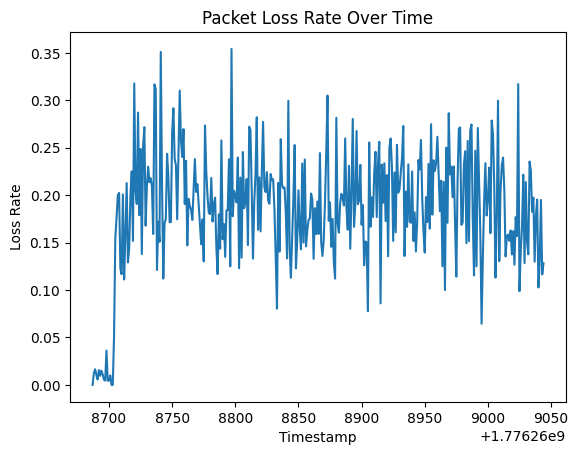

In [1]:
import pandas as pd

# Load the CSV
df = pd.read_csv("stats.csv")

# Compute loss rate: lost / (pkts + lost)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"])

# Group by timestamp and compute average loss rate
loss_rate_per_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

print(loss_rate_per_time.head())


loss_rate_per_time.to_csv("loss_rate_per_time.csv", index=False)

# Plot (optional)
import matplotlib.pyplot as plt
plt.plot(loss_rate_per_time["ts_s"], loss_rate_per_time["loss_rate"])
plt.xlabel("Timestamp")
plt.ylabel("Loss Rate")
plt.title("Packet Loss Rate Over Time")
plt.show()



# this zoom packet had the zoom running for some time 

Mode Applied: Screen Share (Manual)
Optimal Weights: Loss=0.1, FPS=0.4, Jitter=0.5
Accuracy: 80.22%


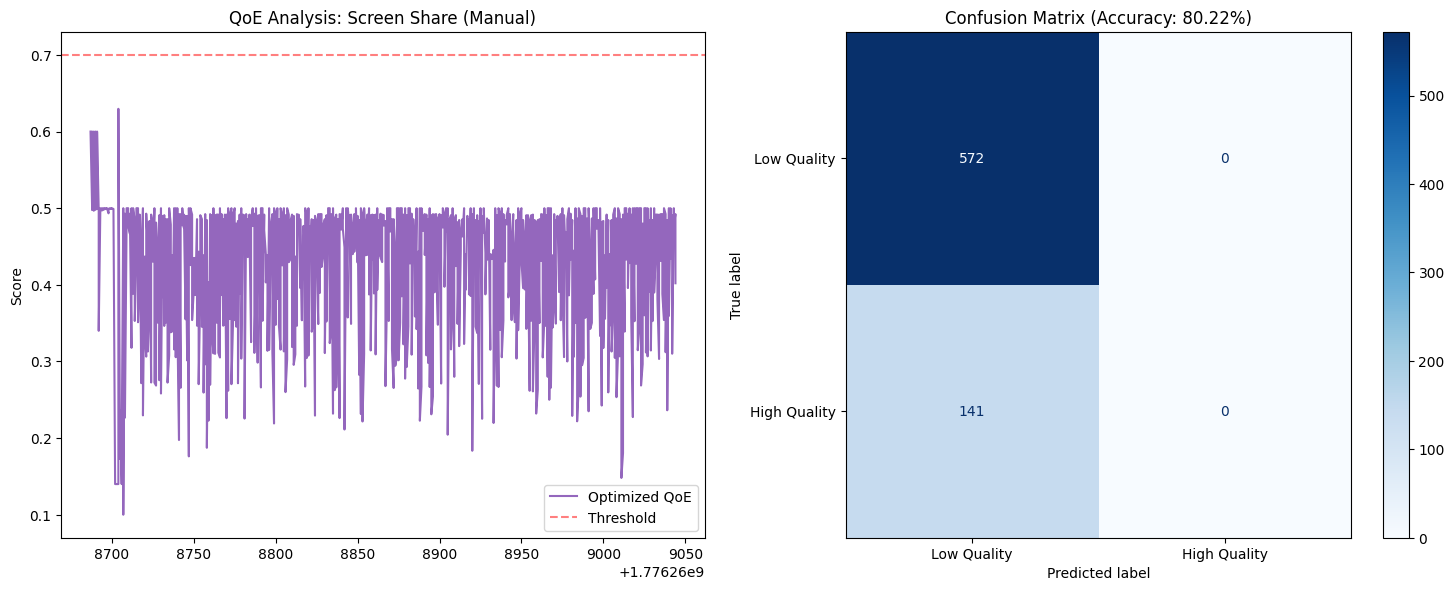

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from itertools import product

# ==========================================
# MANUAL TOGGLE: Set this to True or False
# ==========================================
MANUAL_SCREENSHARE_MODE = True 
# ==========================================

# 1. LOAD AND CLEAN DATA
df = pd.read_csv("stats.csv")
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. METRIC CALCULATION (Adaptive Logic)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Apply Manual Override or Auto-detect
if MANUAL_SCREENSHARE_MODE:
    fps_target = 10      # Screen sharing prioritizes resolution over FPS
    jitter_threshold = 60 # Higher tolerance for jitter in static slides
    mode_label = "Screen Share (Manual)"
else:
    fps_target = 30      # Standard video target
    jitter_threshold = 40 # Standard Zoom recommendation
    mode_label = "Standard Video (Manual)"

# Normalization based on the selected mode
df['fps_norm'] = (df['frames'] / fps_target).clip(0, 1)
if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000
    df['jitter_norm'] = (1 - (df['jitter_ms'] / jitter_threshold)).clip(0, 1)

# 3. DEFINE GROUND TRUTH
# Using your documented "Stressed" threshold of 7.48% loss
df['actual_qoe_bin'] = np.where((df['loss_rate'] > 0.0748) | (df['frames'] < 5), 0, 1)

# 4. OPTIMIZATION: FIND BEST WEIGHTS
def calculate_accuracy(w1, w2, w3, data):
    score = (w1 * (1 - data['loss_rate'])) + (w2 * data['fps_norm']) + (w3 * data['jitter_norm'])
    pred_bin = np.where(score > 0.7, 1, 0)
    return (pred_bin == data['actual_qoe_bin']).mean(), pred_bin

best_acc = 0
best_weights = (0.4, 0.3, 0.3)
weights_range = [np.round(x, 1) for x in np.linspace(0.1, 0.8, 8)]

for w1, w2 in product(weights_range, weights_range):
    w3 = np.round(1.0 - w1 - w2, 1)
    if w3 >= 0.1:
        acc, _ = calculate_accuracy(w1, w2, w3, df)
        if acc > best_acc:
            best_acc = acc
            best_weights = (w1, w2, w3)

print(f"Mode Applied: {mode_label}")
print(f"Optimal Weights: Loss={best_weights[0]}, FPS={best_weights[1]}, Jitter={best_weights[2]}")
print(f"Accuracy: {best_acc:.2%}")

# 5. GENERATE FINAL CONFUSION MATRIX
final_acc, y_pred = calculate_accuracy(*best_weights, df)
y_true = df['actual_qoe_bin']
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Quality', 'High Quality'])

# 6. PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

df['qoe_score'] = (best_weights[0] * (1 - df['loss_rate'])) + \
                  (best_weights[1] * df['fps_norm']) + \
                  (best_weights[2] * df['jitter_norm'])

ax1.plot(df['ts_s'], df['qoe_score'], color='#9467bd', label='Optimized QoE')
ax1.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Threshold')
ax1.set_title(f"QoE Analysis: {mode_label}")
ax1.set_ylabel('Score')
ax1.legend()

disp.plot(ax=ax2, cmap='Blues')
ax2.set_title(f"Confusion Matrix (Accuracy: {best_acc:.2%})")

plt.tight_layout()
plt.show()

#